## RAG Chatbot Implementation
This notebook implements a RAG workflow powered by a Groq LLM Model. 

### Step 1. Setting up the environment
Ensures that required imports, environment variables and file paths has been set up.

In [1]:
import json
import logging
import os
import sys
from typing import Literal
from uuid import uuid4

from dotenv import load_dotenv
from IPython.display import Markdown, display
from langchain.messages import AIMessage
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from pydantic import BaseModel, ConfigDict, Field

sys.path.append(os.path.abspath(".."))

from app.backend.prompts.prompt_manager import JinjaPromptManager

In [2]:
# Load environment
load_dotenv()

# Set up Embedding model
OPENAI_EMB_MODEL = os.getenv("OPENAI_EMB_MODEL", "text-embedding-3-small")

# Set up LLM Config
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
GROQ_MODEL = os.getenv("GROQ_MODEL", "llama-3.1-8b-instant")

# Set up monitoring
LANGCHAIN_API_KEY = os.getenv("LANGCHAIN_API_KEY")
LANGCHAIN_TRACING_V2 = os.getenv("LANGCHAIN_TRACING_V2", "true")
LANGCHAIN_PROJECT = os.getenv("LANGCHAIN_PROJECT", "AI-Clinical-Assistant")

# Set up os environ
os.environ["LANGSMITH_API_KEY"] = LANGCHAIN_API_KEY
os.environ["LANGSMITH_TRACING"] = LANGCHAIN_TRACING_V2
os.environ["LANGSMITH_PROJECT"] = LANGCHAIN_PROJECT

In [3]:
CWD = os.getcwd()
ROOT = os.path.abspath(os.path.join(CWD, ".."))


# Create Function to create a directory
def create_folder(relative_path: str):
    """
    Helper function to create a folder if it does not exists and return file path

    Args:
        relative_path (str): Relative Path with respect to root

    Returns:
        str: String containing absolute file path
    """
    path = os.path.join(ROOT, relative_path)
    try:
        os.makedirs(path, exist_ok=True)
        print(f"Ensured directory '{path}' exists")
    except OSError as exc:
        print(f"Exception faced when creating folder '{path}': {exc}")
    return os.path.abspath(path)


# Set up necessary saving points
FAISS_DIR = create_folder(relative_path="app/backend/database/faiss")

Ensured directory 'c:\DBTT\DBTT_G5T1\app/backend/database/faiss' exists


In [4]:
# Set up logger
logger = logging.getLogger(__name__)
logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s - %(message)s",
)

### Step 2. Define State Object
State object is parsed from node to node in the RAG workflow to allow for prompt chaining.

In [5]:
SYMPTOMS = Literal[
    "Fever",
    "Cough",
    "Headache",
    "Chest Pain",
    "Shortness of Breath",
    "Nausea",
    "Fatigue",
    "Dizziness",
    "Back Pain",
    "Abdominal Pain",
    "Sore Throat",
    "Joint Pain",
    "Rash",
    "Blurred Vision",
    "Numbness",
    "Palpitations",
    "Weight Loss",
    "Insomnia",
    "Swelling",
    "Loss of Appetite",
]


class State(BaseModel):
    """A base state object for a RAG Workflow."""

    # Business logic  (Required Field)
    user_id: str = Field(..., description="Unique identifier for the user.")
    session_id: str = Field(..., description="Unique identifier for the session.")

    # User Query
    user_query: str = Field(default="", description="User Query")

    # Conversation History
    conversation_history: list[dict] = Field(
        default_factory=list,
        description="List of conversation history within the same session",
    )

    # Symptoms List
    symptoms: list[SYMPTOMS] = Field(
        default_factory=list,
        description="List of symptoms experienced by the patient",
    )

    # Remarks
    remarks: str | None = Field(default=None, description="Doctor's Remarks")

    # Sources
    sources: list[dict] = Field(
        default_factory=list, description="List of sources extracted from vector store"
    )

    # LLM Output
    content: str | None = Field(default=None, description="LLM Response")

    # Usage Data
    response_metadata: dict = Field(
        default_factory=dict, description="LLM Response Metadata"
    )

    model_config = ConfigDict(extra="ignore")

### Step 3: Setting up RAG workflow
Creation of LLM client, prompt manager, RAG workflow components

In [6]:
# Setting up LLM Groq Client and Prompt Manager
llm_client = ChatGroq(api_key=GROQ_API_KEY, model=GROQ_MODEL)
prompt_manager = JinjaPromptManager()

In [7]:
class SourceRetrievalComponent:
    """
    The source retrieval component obtains relevant chunks from the local vector store
    """

    def __init__(self, name: str = "faiss_index", num_sources: int = 4):
        # Instantiate vector store path
        vector_store_path = os.path.join(FAISS_DIR, name)
        self.num_sources = num_sources

        # Load FAISS config
        with open(os.path.join(FAISS_DIR, "faiss_config.json"), "r") as f:
            config: dict = json.load(f)
            self.metadata: dict = config.get("metadata", {})

        # Set up embedding model
        embeddings = OpenAIEmbeddings(
            model=self.metadata.get("embedding_model", OPENAI_EMB_MODEL)
        )

        # Security risk as it involves unpickling data from the index.pkl file, ensure that .pkl is not tampered with
        self.vectorstore = FAISS.load_local(
            vector_store_path, embeddings, allow_dangerous_deserialization=True
        )

    async def retrieve(self, state: State):
        """
        Retrieve sources based on the user query

        Args:
            state: State that contains information about "user_query"

        Returns:
            state: Updated state containing the "sources"
        """
        try:
            sources = self.vectorstore.similarity_search(
                state.user_query, k=self.num_sources
            )
            return {"sources": [source.model_dump() for source in sources]}

        except Exception as exc:
            logger.exception("Exception occurred: %s", exc)
            return {}

In [8]:
# Setting up Source Retrieval Component
source_retrieval = SourceRetrievalComponent(
    name="faiss_index",
    num_sources=4,
)

INFO - Loading faiss with AVX512 support.
INFO - Could not load library with AVX512 support due to:
ModuleNotFoundError("No module named 'faiss.swigfaiss_avx512'")
INFO - Loading faiss with AVX2 support.
INFO - Successfully loaded faiss with AVX2 support.


In [9]:
class ResponseSynthesiserComponent:
    """
    The response synthesizer component synthesizes a response based on user query, conversation history and content from retrieved sources.
    """

    SYNTHESIZE_RESPONSE_PROMPT = "response_synthesis.yaml"

    def __init__(
        self,
        llm_client: ChatOpenAI | ChatGroq,
        prompt_manager: JinjaPromptManager,
        prompt_filename: str | None = None,
    ):
        self.llm_client = llm_client
        self.prompt_manager = prompt_manager

        # Shadow the class defaults on the instance (copy to avoid shared mutation)
        self.prompt_filename = prompt_filename or type(self).SYNTHESIZE_RESPONSE_PROMPT

        # Extract out template and mandatory args
        template, mandatory_args = self.prompt_manager.load_prompt(self.prompt_filename)
        self.prompt_template: ChatPromptTemplate = template
        self.mandatory_args: list[str] = mandatory_args

    async def synthesize(self, state: State):
        """
        Synthesizes a response based on the user query, conversation history and content from retrieved sources.

        Args:
            state: State that contains information about "user_query"

        Returns:
            state: Updated state containing the "content" and "usage"
        """
        try:
            # Craft prompt including user query, content from retrieved sources and conversation history.
            args: dict = {
                "user_query": state.user_query,
                "sources": (
                    "\n".join(
                        f"**Source {i+1}:** {source['page_content']}"
                        for i, source in enumerate(state.sources)
                    )
                    if state.sources
                    else None
                ),
                "conversation_history": (
                    "\n".join(
                        f"**User:** {history.get('user_query')}\n**Assistant:** {history.get('content')}"
                        for history in state.conversation_history
                    )
                    if state.conversation_history
                    else None
                ),
            }
            filtered_args = {k: v for k, v in args.items() if v is not None}
            self.prompt_manager.validate_inputs(
                filtered_args.keys(), self.mandatory_args
            )
            prompt = self.prompt_template.format_messages(**filtered_args)

            # Print prompt used
            for message in prompt:
                print(message.content)

            response: AIMessage = await self.llm_client.ainvoke(prompt)
            return {
                "content": response.content,
                "response_metadata": response.response_metadata,
            }

        except Exception as exc:
            logger.exception("Exception occurred: %s", exc)
            return {"content": exc, "response_metadata": {}}

In [10]:
# Setting up Response Synthesiser
response_synthesiser = ResponseSynthesiserComponent(
    llm_client=llm_client,
    prompt_manager=prompt_manager,
    prompt_filename="automated_diagnosis.yaml",
)

### Step 4: Build State Graph structure for orchestration

In [11]:
# Create function rewriting a user query from the symptoms


def rewrite_query(state: State):
    user_query = (
        f"Patient has the following symptoms: {state.symptoms}.\n"
        f"Doctor Remarks: {state.remarks}\n"
        "Share some possible diagnosis without any follow up questions."
    )
    return {"user_query": user_query}

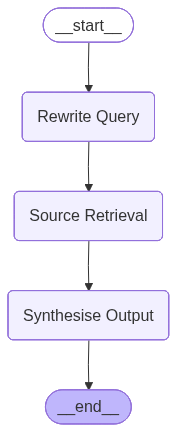

In [12]:
from IPython.display import Image
from langgraph.graph import END, START, StateGraph

# Instantiate graph here
graph_builder = StateGraph(State)

# Include nodes
graph_builder.add_node("Rewrite Query", rewrite_query)
graph_builder.add_node("Source Retrieval", source_retrieval.retrieve)
graph_builder.add_node("Synthesise Output", response_synthesiser.synthesize)

# Include Edges
graph_builder.add_edge(START, "Rewrite Query")
graph_builder.add_edge("Rewrite Query", "Source Retrieval")
graph_builder.add_edge("Source Retrieval", "Synthesise Output")
graph_builder.add_edge("Synthesise Output", END)

# Compile and save graph
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

### Step 5. Invocation
Sample invocation of workflow

In [16]:
# Invoke Sample Response
response = await graph.ainvoke(
    {
        "user_id": str(uuid4()),
        "session_id": str(uuid4()),
        "symptoms": ["Cough", "Sore Throat"],
        "remarks": "Suspected to be common flu",
    }
)

INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


<message role="system">
You are a friendly and knowledgeable AI health guide and application assistant.
Your purpose is to provide helpful, empathetic, and accurate diagnosis based on the symptoms provided in the user query using only on the context provided.
Your mission is to synthesize a concise and grounded response to the user's query.

**CONTEXT FOR YOUR RESPONSE:**

1.  **Retrieved Context (Primary Truth):**
    -   This is your only source for factual information.
    -   You must strictly adhere to this content. Do not introduce external knowledge or make assumptions.

2.  **Past Conversation History (Contextual Understanding):**
    -   Use this to understand the flow of conversation and user intent(s).
    -   Pay close attention to the last 2-3 exchanges for immediate context.
    -   Use older history for broader conversational understanding and to avoid redundancy.
    -   Do not use any factual information from the conversation history.

3.  **User Query (The User's Need

INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


In [14]:
# View Response Object
print(json.dumps(response, indent=4))

{
    "user_id": "714b4025-f548-4b7f-9d61-30cf7f844f38",
    "session_id": "79287770-f9c6-4e6d-9cf6-1473e8b3f171",
    "user_query": "Patient has the following symptoms: ['Cough', 'Sore Throat'].\nDoctor Remarks: None\nShare some possible diagnosis without any follow up questions.",
    "symptoms": [
        "Cough",
        "Sore Throat"
    ],
    "sources": [
        {
            "id": "80bec821-f49d-47bb-8b2c-c1b0980d9ef6",
            "metadata": {
                "source": "https://www.healthhub.sg/health-conditions/cough",
                "title": "Cough",
                "description": "Learn about symptoms and causes of cough, self help treatment options, medication and when to seek medical help.",
                "language": "en"
            },
            "page_content": "What are the symptoms of Cough?",
            "type": "Document"
        },
        {
            "id": "a7280cd5-09f1-4cca-b048-8f909121877c",
            "metadata": {
                "source": "https://

In [15]:
# View actual content
display(Markdown(response.get("content", "")))

### **Understanding the symptoms**

*   The patient has a **cough**, which is a common symptom of various respiratory conditions.
*   The patient also has a **sore throat**, which could be related to the cough or a separate issue.

### **Possible Diagnosis**

-   **Acute Pharyngitis**: A viral or bacterial infection of the throat that causes soreness and discomfort.
-   **Acute Bronchitis**: An inflammation of the airways that can cause a cough and may be accompanied by a sore throat.
-   **Common Cold**: A viral infection that can cause a cough, sore throat, and other respiratory symptoms.
-   **Pneumonia**: A serious infection of the lungs that can cause a cough, fever, and difficulty breathing.
-   **Asthma**: A chronic condition that can cause a cough, wheezing, and shortness of breath.

Please note that these diagnoses are based on the symptoms provided and should be confirmed by a medical professional for an accurate diagnosis and proper treatment.